# Authentication and Authorization Hardening - End-to-End Pipeline
**Date**: 2026-05-31  
**Objective**: Evaluate identity and policy controls for least-privilege access paths.


## 1. Imports and Setup


In [1]:
from __future__ import annotations

import os
from pathlib import Path
import sys

import pandas as pd

module_dir = Path('vulnerability-defenses').resolve()
if str(module_dir) not in sys.path:
    sys.path.append(str(module_dir))

from shared_vulnerability_notebook_lib import (
    DefenseConfig,
    TOPIC_PROFILES,
    build_dataset,
    build_summary,
    evaluate,
    parse_use_gpu_flag,
    persist_metrics,
    plot_metric_bars,
    plot_score_hist,
    predict_scores,
    prepare_features,
    quick_eda,
    resolve_runtime_device,
    set_reproducibility,
    train_logistic,
)

SEED = 42
set_reproducibility(SEED)
USE_GPU = parse_use_gpu_flag(os.getenv('USE_GPU', '1'))
runtime_device = resolve_runtime_device(USE_GPU)
print(f'USE_GPU={int(USE_GPU)} | runtime_device={runtime_device}')
            


USE_GPU=1 | runtime_device=cuda


## 2. Configuration and Constants


In [2]:
CFG = DefenseConfig(
    topic_key='authn-authz-hardening',
    topic_title='Authentication and Authorization Hardening',
    seed=SEED,
    test_ratio=0.25,
    threshold=0.57,
    output_dir=Path('vulnerability-defenses/outputs'),
)
PROFILE = TOPIC_PROFILES[CFG.topic_key]
CFG
            


DefenseConfig(topic_key='authn-authz-hardening', topic_title='Authentication and Authorization Hardening', seed=42, test_ratio=0.25, threshold=0.57, output_dir=PosixPath('vulnerability-defenses/outputs'))

## 3. Data Loading


In [3]:
df = build_dataset(CFG, PROFILE, n_samples=260)
print(f'rows={len(df)} cols={len(df.columns)}')
df.head()
            


rows=260 cols=6


,input_exposure,identity_gap,telemetry_alert,blast_radius,dependency_exposure,incident
0,0.773956,0.146173,0.856548,0.254263,0.091724,1
1,0.438878,0.824664,0.372262,0.918794,0.667490,1
2,0.858598,0.310335,0.153613,0.454457,0.655518,1
3,0.697368,0.143872,0.600840,0.603424,0.662910,1
4,0.094177,0.920970,0.119673,0.984650,0.019766,1


## 4. Exploratory Data Analysis (EDA)


In [4]:
eda = quick_eda(df)
print('incident_rate:', round(eda['incident_rate'], 4))
pd.Series(eda['feature_mean']).sort_values(ascending=False)
            


incident_rate: 1.0


blast_radius           0.507
input_exposure         0.495
identity_gap           0.495
telemetry_alert        0.495
dependency_exposure    0.493
dtype: float64

## 5. Preprocessing / Feature Engineering


In [5]:
x_train, y_train, x_test, y_test = prepare_features(
    df=df,
    test_ratio=CFG.test_ratio,
    seed=CFG.seed,
)
print(
    f'x_train={x_train.shape}, y_train={y_train.shape}, '
    f'x_test={x_test.shape}, y_test={y_test.shape}'
)
            


x_train=(195, 5), y_train=(195,), x_test=(65, 5), y_test=(65,)


## 6. Model Definition


In [6]:
EPOCHS = 320
LEARNING_RATE = 0.11
print(f'epochs={EPOCHS} learning_rate={LEARNING_RATE}')
            


epochs=320 learning_rate=0.11


## 7. Training


In [7]:
w, b, losses = train_logistic(
    x_train=x_train,
    y_train=y_train,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
)
print(f'final_loss={losses[-1]:.4f}')
            


final_loss=0.0301


## 8. Evaluation and Metrics


In [8]:
test_scores = predict_scores(x_test, w, b)
metrics = evaluate(y_true=y_test, scores=test_scores, threshold=0.5)
metrics
            


{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

## 9. Results Visualization


metrics saved to: vulnerability-defenses/outputs/authn-authz-hardening_metrics.json


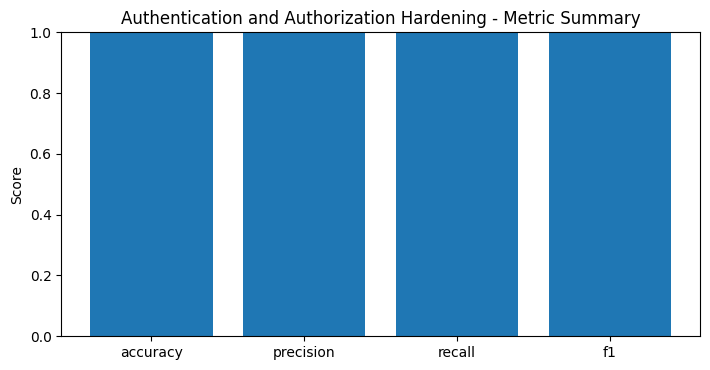

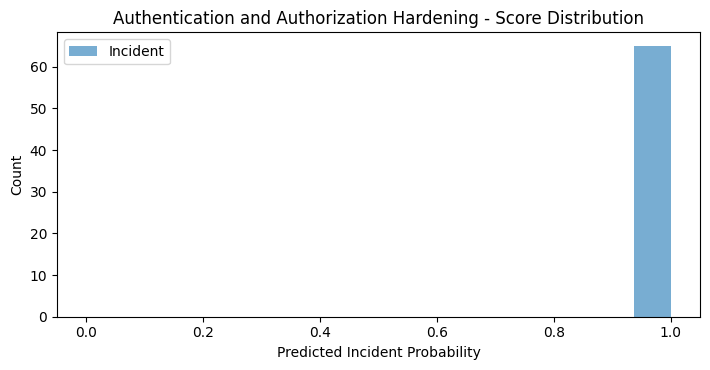

In [9]:
plot_metric_bars(metrics, 'Authentication and Authorization Hardening - Metric Summary')
plot_score_hist(test_scores, y_test, 'Authentication and Authorization Hardening - Score Distribution')
metrics_path = persist_metrics(CFG, metrics)
print(f'metrics saved to: {metrics_path}')
            


## 10. Summary / Conclusions


In [10]:
summary = build_summary(CFG.topic_title, metrics, runtime_device)
print(summary)
print('Use this baseline to tune thresholds and rollout controls per environment.')
            


Authentication and Authorization Hardening: accuracy=1.0, f1=1.0, runtime_device=cuda.
Use this baseline to tune thresholds and rollout controls per environment.
